# Neighborhoods Exploratory Data Analysis

This notebook performs an exploratory data analysis on Barcelona neighborhoods, focusing on income levels, population, and geographic visualization.

## 1. Import Required Libraries

In [16]:
import warnings
from pathlib import Path
import difflib
import unicodedata

import pandas as pd
import geopandas as gpd
from shapely import wkt

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

## 2. Load Neighborhoods Data

In [20]:
BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw_csv"

INCOME_CSV = RAW_DIR / "income_normalized_by_neighborhood.csv"
GEOMETRIES_CSV = RAW_DIR / "neighborhoods_polygons_opendata.csv"
POP_TOTAL_CSV = RAW_DIR / "2025_pad_mdbas.csv"

MANUAL_OVERRIDES = {
    "la Marina del Prat Vermell - AEI Zona Franca": "la Marina del Prat Vermell",
    "el Poble Sec": "el Poble-sec",
    "el Gotic": "el Barri Gotic",
}


def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    return " ".join(text.split())


def prepare_geometries(path: Path) -> gpd.GeoDataFrame:
    df = pd.read_csv(path)
    df["codi_barri"] = df["codi_barri"].astype(int)

    geom_col = [col for col in df.columns if "geom" in col.lower() or "wkt" in col.lower()][0]
    df["geometry"] = df[geom_col].apply(wkt.loads)
    keep_cols = ["codi_barri", "nom_barri", "nom_districte", "geometry"]
    df = df[keep_cols].copy()

    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:25831")
    gdf = gdf.to_crs("EPSG:4326")
    gdf["join_key"] = gdf["nom_barri"].map(normalize_text)
    return gdf


def match_to_master(names: pd.Series, master_keys: set[str], master_lookup: dict[str, str]) -> pd.Series:
    matched = []
    for name in names:
        original_key = normalize_text(name)
        overridden_name = MANUAL_OVERRIDES.get(str(name).strip(), str(name).strip())
        override_key = normalize_text(overridden_name)

        if override_key in master_keys:
            matched.append(override_key)
            continue

        if original_key in master_keys:
            matched.append(original_key)
            continue

        fuzzy = difflib.get_close_matches(override_key, list(master_keys), n=1, cutoff=0.75)
        matched.append(fuzzy[0] if fuzzy else None)

    return pd.Series(matched)


neighborhoods_gdf = prepare_geometries(GEOMETRIES_CSV)
master_keys = set(neighborhoods_gdf["join_key"])
master_lookup = dict(zip(neighborhoods_gdf["join_key"], neighborhoods_gdf["nom_barri"]))

income_raw = pd.read_csv(INCOME_CSV)
income_df = income_raw[income_raw["Tipus de territori"] == "Barri"].copy()
income_df["income_2022"] = income_df["2022"].str.replace(",", ".", regex=False).astype(float)
income_df = income_df.rename(columns={"Territori": "nom_barri"})[["nom_barri", "income_2022"]]
income_df["join_key"] = match_to_master(income_df["nom_barri"], master_keys, master_lookup)
income_df = income_df.dropna(subset=["join_key"])
income_df["nom_barri"] = income_df["join_key"].map(master_lookup)
income_df = income_df.groupby(["join_key", "nom_barri"], as_index=False)["income_2022"].mean()

population_raw = pd.read_csv(POP_TOTAL_CSV)
neighborhoods_pop = (
    population_raw.groupby("Nom_Barri", as_index=False)["Valor"]
    .sum()
    .rename(columns={"Nom_Barri": "nom_barri", "Valor": "population_total"})
)
neighborhoods_pop["join_key"] = match_to_master(neighborhoods_pop["nom_barri"], master_keys, master_lookup)
neighborhoods_pop = neighborhoods_pop.dropna(subset=["join_key"])
neighborhoods_pop["nom_barri"] = neighborhoods_pop["join_key"].map(master_lookup)
neighborhoods_pop = neighborhoods_pop.groupby(["join_key", "nom_barri"], as_index=False)["population_total"].sum()

analysis_df = (
    neighborhoods_gdf[["codi_barri", "nom_barri", "nom_districte", "join_key", "geometry"]]
    .merge(income_df[["join_key", "income_2022"]], on="join_key", how="left")
    .merge(neighborhoods_pop[["join_key", "population_total"]], on="join_key", how="left")
)

print("Loaded datasets:")
print(f"- neighborhoods_gdf: {len(neighborhoods_gdf)} rows")
print(f"- income_df: {len(income_df)} rows")
print(f"- neighborhoods_pop: {len(neighborhoods_pop)} rows")
print(f"- analysis_df: {len(analysis_df)} rows")
print("\nMissing values in merged dataset:")
print(analysis_df[["income_2022", "population_total"]].isna().sum())

Loaded datasets:
- neighborhoods_gdf: 73 rows
- income_df: 60 rows
- neighborhoods_pop: 73 rows
- analysis_df: 73 rows

Missing values in merged dataset:
income_2022         13
population_total     0
dtype: int64


## 3. Explore Data Structure

In [6]:
print("=== Neighborhoods Geographic Data ===")
print(neighborhoods_gdf.head())
print(f"\nColumns: {neighborhoods_gdf.columns.tolist()}")
print(f"CRS: {neighborhoods_gdf.crs}")

print("\n=== Income Data ===")
print(income_df.head())
print(f"\nColumns: {income_df.columns.tolist()}")

print("\n=== Population Data ===")
print(neighborhoods_pop.head())
print(f"\nColumns: {neighborhoods_pop.columns.tolist()}")

print("\n=== Merged Analysis Data ===")
print(analysis_df[["codi_barri", "nom_barri", "income_2022", "population_total"]].head())

=== Neighborhoods Geographic Data ===
   codi_barri                              nom_barri nom_districte  \
0           1                               el Raval  Ciutat Vella   
1           2                         el Barri Gòtic  Ciutat Vella   
2           3                         la Barceloneta  Ciutat Vella   
3           4  Sant Pere, Santa Caterina i la Ribera  Ciutat Vella   
4           5                          el Fort Pienc      Eixample   

                                            geometry  \
0  POLYGON ((430162.1875 4581936.9845, 430102.838...   
1  POLYGON ((431189.9075 4581851.4475, 431025.789...   
2  POLYGON ((432798.73413 4582081.25995, 432794.0...   
3  POLYGON ((431733.736 4582441.816, 431557.5115 ...   
4  POLYGON ((431741.8152 4582625.6491, 432012.183...   

                                join_key  
0                               el raval  
1                         el barri gotic  
2                         la barceloneta  
3  sant pere, santa caterina i l

In [7]:
print(f"Total neighborhoods in geographic data: {len(neighborhoods_gdf)}")
print(f"Total neighborhoods with income: {analysis_df['income_2022'].notna().sum()}")
print(f"Total neighborhoods with population: {analysis_df['population_total'].notna().sum()}")

print("\nTop 10 neighborhoods by income:")
print(
    analysis_df[["nom_barri", "income_2022"]]
    .dropna()
    .sort_values("income_2022", ascending=False)
    .head(10)
)

print("\nTop 10 neighborhoods by population:")
print(
    analysis_df[["nom_barri", "population_total"]]
    .dropna()
    .sort_values("population_total", ascending=False)
    .head(10)
)

Total neighborhoods in geographic data: 73
Total neighborhoods with income: 60
Total neighborhoods with population: 73

Top 10 neighborhoods by income:
                             nom_barri  income_2022
29                            la Salut       180.18
25              Sant Gervasi - Galvany       166.37
30                   la Vila de Gràcia       157.18
31  el Camp d'en Grassot i Gràcia Nova       156.92
28                             el Coll       154.27
32                    el Baix Guinardó       129.08
9                          Sant Antoni       128.93
27           Vallcarca i els Penitents       126.69
23                     les Tres Torres       126.28
34                         el Guinardó       115.94

Top 10 neighborhoods by population:
                          nom_barri  population_total
8    la Nova Esquerra de l'Eixample             59122
59                      Sant Andreu             58988
5                la Sagrada Família             53555
30                la Vi

## 4. Income Analysis by Neighborhood

In [8]:
print("=== Income Statistics ===")
print(analysis_df[["income_2022"]].describe())

income_cols = ["income_2022"]
print(f"\nIncome columns used for analysis: {income_cols}")

=== Income Statistics ===
       income_2022
count    60.000000
mean     94.582333
std      28.623238
min      51.270000
25%      76.710000
50%      90.355000
75%     108.787500
max     180.180000

Income columns used for analysis: ['income_2022']


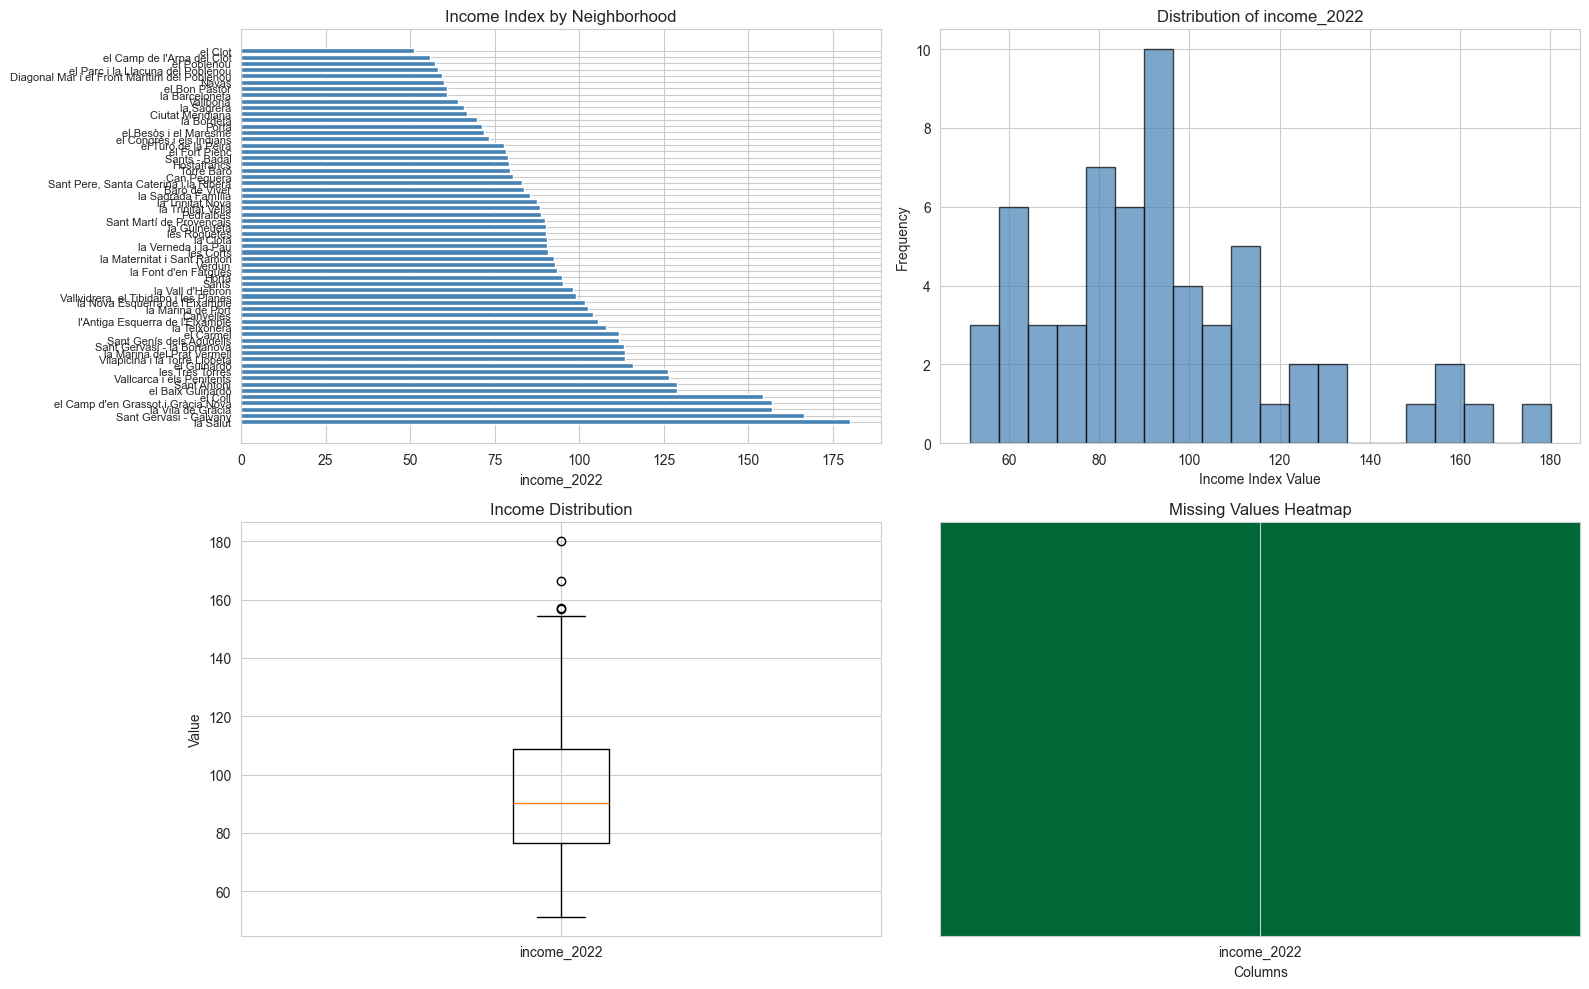

Highest income neighborhood: la Salut
Lowest income neighborhood: el Clot


In [9]:
income_plot_df = analysis_df[["nom_barri", "income_2022"]].dropna().copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

income_sorted = income_plot_df.sort_values("income_2022", ascending=False)
axes[0, 0].barh(income_sorted["nom_barri"], income_sorted["income_2022"], color="steelblue")
axes[0, 0].set_xlabel("income_2022")
axes[0, 0].set_title("Income Index by Neighborhood")
axes[0, 0].tick_params(axis="y", labelsize=8)

axes[0, 1].hist(income_plot_df["income_2022"], bins=20, color="steelblue", edgecolor="black", alpha=0.7)
axes[0, 1].set_xlabel("Income Index Value")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Distribution of income_2022")

axes[1, 0].boxplot([income_plot_df["income_2022"]], labels=["income_2022"])
axes[1, 0].set_ylabel("Value")
axes[1, 0].set_title("Income Distribution")

axes[1, 1].imshow(income_plot_df[["income_2022"]].isna().astype(int), cmap="RdYlGn_r", aspect="auto")
axes[1, 1].set_title("Missing Values Heatmap")
axes[1, 1].set_xlabel("Columns")
axes[1, 1].set_yticks([])
axes[1, 1].set_xticks([0])
axes[1, 1].set_xticklabels(["income_2022"])

plt.tight_layout()
plt.show()

print(f"Highest income neighborhood: {income_sorted.iloc[0]['nom_barri']}")
print(f"Lowest income neighborhood: {income_sorted.iloc[-1]['nom_barri']}")

## 5. Population Analysis by Neighborhood

In [10]:
print("=== Population Statistics ===")
print(analysis_df[["population_total"]].describe())

pop_cols = ["population_total"]
print(f"\nPopulation columns used for analysis: {pop_cols}")

=== Population Statistics ===
       population_total
count         73.000000
mean       23726.931507
std        15154.606277
min         1071.000000
25%        11351.000000
50%        22767.000000
75%        31647.000000
max        59122.000000

Population columns used for analysis: ['population_total']


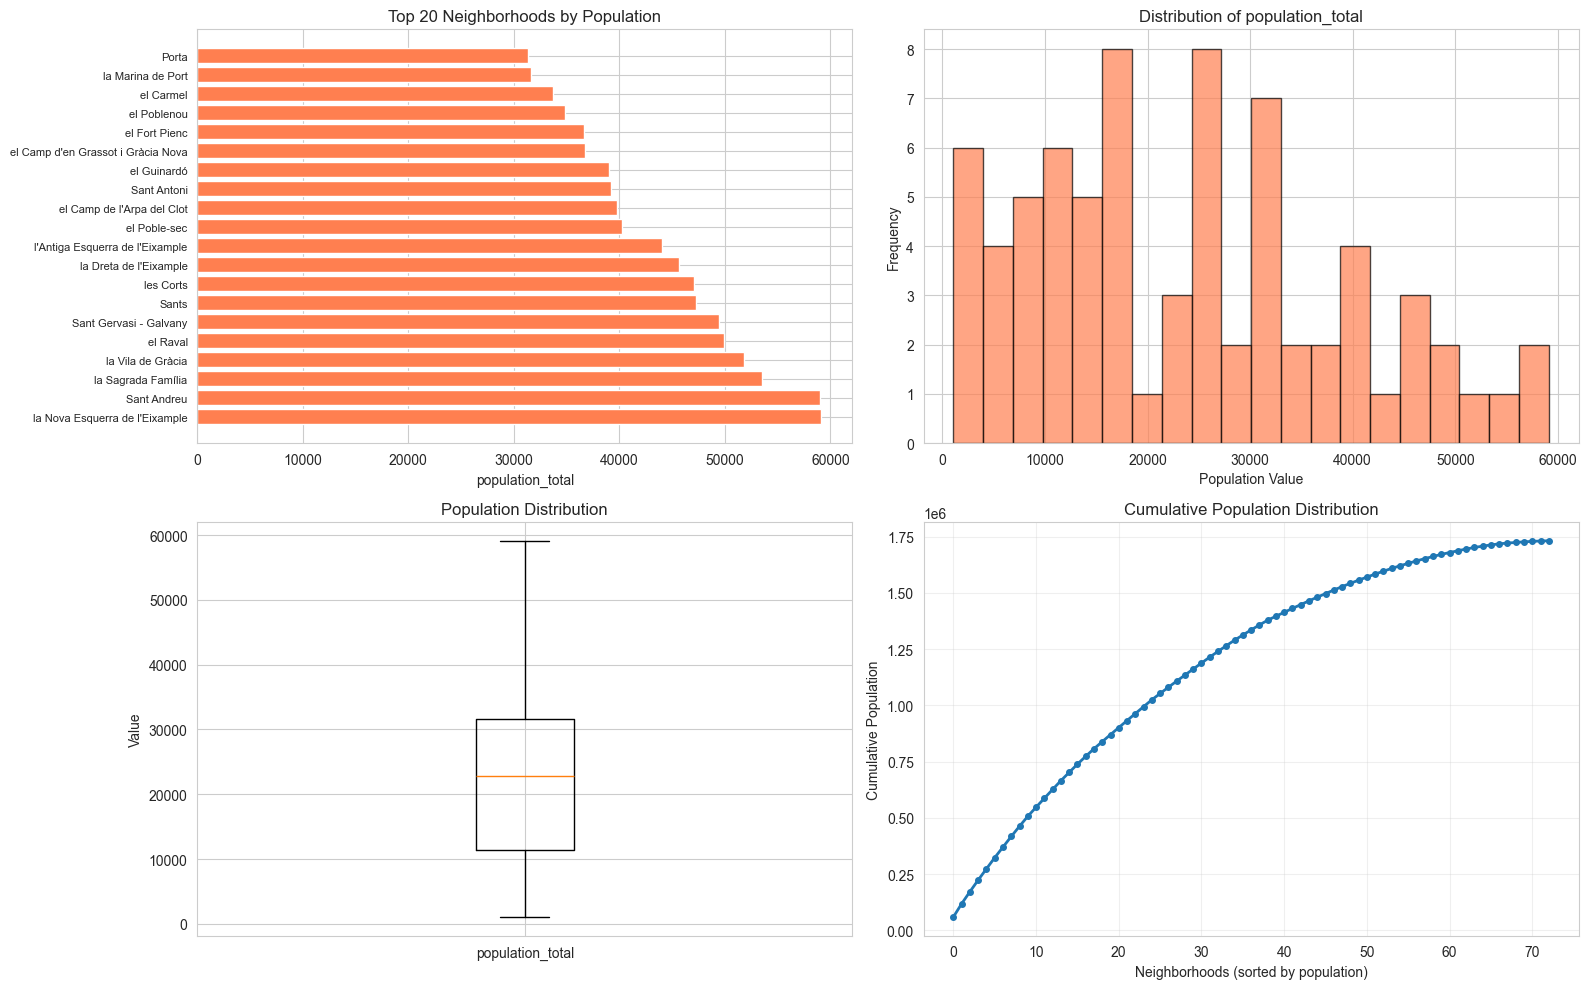


Total population: 1,732,066
Average population per neighborhood: 23,727
Highest population neighborhood: la Nova Esquerra de l'Eixample
Lowest population neighborhood: la Clota


In [11]:
pop_plot_df = analysis_df[["nom_barri", "population_total"]].dropna().copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pop_sorted = pop_plot_df.sort_values("population_total", ascending=False).head(20)
axes[0, 0].barh(pop_sorted["nom_barri"], pop_sorted["population_total"], color="coral")
axes[0, 0].set_xlabel("population_total")
axes[0, 0].set_title("Top 20 Neighborhoods by Population")
axes[0, 0].tick_params(axis="y", labelsize=8)

axes[0, 1].hist(pop_plot_df["population_total"], bins=20, color="coral", edgecolor="black", alpha=0.7)
axes[0, 1].set_xlabel("Population Value")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Distribution of population_total")

axes[1, 0].boxplot([pop_plot_df["population_total"]], labels=["population_total"])
axes[1, 0].set_ylabel("Value")
axes[1, 0].set_title("Population Distribution")

pop_sorted_cum = pop_plot_df["population_total"].sort_values(ascending=False)
cum_sum = pop_sorted_cum.cumsum()
axes[1, 1].plot(range(len(cum_sum)), cum_sum.values, marker="o", linewidth=2, markersize=4)
axes[1, 1].set_xlabel("Neighborhoods (sorted by population)")
axes[1, 1].set_ylabel("Cumulative Population")
axes[1, 1].set_title("Cumulative Population Distribution")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal population: {pop_plot_df['population_total'].sum():,.0f}")
print(f"Average population per neighborhood: {pop_plot_df['population_total'].mean():,.0f}")
print(f"Highest population neighborhood: {pop_sorted.iloc[0]['nom_barri']}")
print(f"Lowest population neighborhood: {pop_plot_df.sort_values('population_total').iloc[0]['nom_barri']}")

## 6. Visualize Neighborhoods on Map

In [24]:
analysis_gdf = gpd.GeoDataFrame(analysis_df.copy(), geometry="geometry", crs=neighborhoods_gdf.crs)

center_lat = analysis_gdf.geometry.centroid.y.mean()
center_lon = analysis_gdf.geometry.centroid.x.mean()
print(f"Map center: ({center_lat:.5f}, {center_lon:.5f})")

income_min = analysis_gdf["income_2022"].min()
income_max = analysis_gdf["income_2022"].max()
population_min = analysis_gdf["population_total"].min()
population_max = analysis_gdf["population_total"].max()

Map center: (41.41132, 2.16467)


In [27]:
from branca.colormap import linear
from IPython.display import display

income_colormap = linear.YlOrRd_09.scale(income_min, income_max)
income_colormap.caption = "Income 2022 (heatmap palette)"

population_colormap = linear.YlGnBu_09.scale(population_min, population_max)
population_colormap.caption = "Population Total (heatmap palette)"


def metric_color(value, colormap):
    if pd.isna(value):
        return "#d9d9d9"
    return colormap(value)


# Income heatmap map
m_income = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="CartoDB positron")

for _, row in analysis_gdf.iterrows():
    income_text = f"{row['income_2022']:.2f}" if pd.notna(row["income_2022"]) else "N/A"
    population_text = f"{int(row['population_total'])}" if pd.notna(row["population_total"]) else "N/A"

    popup_text = (
        f"<b>{row['nom_barri']}</b><br>"
        f"District: {row['nom_districte']}<br>"
        f"Income 2022: {income_text}<br>"
        f"Population: {population_text}"
    )

    fill_color = metric_color(row["income_2022"], income_colormap)

    folium.GeoJson(
        data=row.geometry.__geo_interface__,
        style_function=lambda x, color=fill_color: {
            "fillColor": color,
            "color": "#333333",
            "weight": 0.8,
            "fillOpacity": 0.8,
        },
        tooltip=folium.Tooltip(f"{row['nom_barri']} | Income: {income_text}"),
        popup=folium.Popup(popup_text, max_width=280),
    ).add_to(m_income)

income_colormap.add_to(m_income)


# Population heatmap map
m_population = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="CartoDB positron")

for _, row in analysis_gdf.iterrows():
    income_text = f"{row['income_2022']:.2f}" if pd.notna(row["income_2022"]) else "N/A"
    population_text = f"{int(row['population_total'])}" if pd.notna(row["population_total"]) else "N/A"

    popup_text = (
        f"<b>{row['nom_barri']}</b><br>"
        f"District: {row['nom_districte']}<br>"
        f"Income 2022: {income_text}<br>"
        f"Population: {population_text}"
    )

    fill_color = metric_color(row["population_total"], population_colormap)

    folium.GeoJson(
        data=row.geometry.__geo_interface__,
        style_function=lambda x, color=fill_color: {
            "fillColor": color,
            "color": "#333333",
            "weight": 0.8,
            "fillOpacity": 0.8,
        },
        tooltip=folium.Tooltip(f"{row['nom_barri']} | Population: {population_text}"),
        popup=folium.Popup(popup_text, max_width=280),
    ).add_to(m_population)

population_colormap.add_to(m_population)

income_map_path = BASE_DIR / "reports" / "figures" / "neighborhoods_income_heatmap.html"
population_map_path = BASE_DIR / "reports" / "figures" / "neighborhoods_population_heatmap.html"

m_income.save(str(income_map_path))
m_population.save(str(population_map_path))

print(f"Income heatmap saved to: {income_map_path}")
print(f"Population heatmap saved to: {population_map_path}")

print("\nIncome heatmap preview:")
display(m_income)
print("\nPopulation heatmap preview:")
display(m_population)

Income heatmap saved to: ..\reports\figures\neighborhoods_income_heatmap.html
Population heatmap saved to: ..\reports\figures\neighborhoods_population_heatmap.html

Income heatmap preview:



Population heatmap preview:


## 7. Summary Statistics & Correlation Analysis

In [22]:
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS SUMMARY - BARCELONA NEIGHBORHOODS")
print("=" * 60)

print("\n### GEOGRAPHIC DATA ###")
print(f"Total neighborhoods: {len(analysis_gdf)}")
print(f"CRS: {analysis_gdf.crs}")
print(f"Bounding box: {analysis_gdf.total_bounds}")

print("\n### INCOME DATA ###")
print(f"Mean income_2022: {analysis_gdf['income_2022'].mean():.4f}")
print(f"Median income_2022: {analysis_gdf['income_2022'].median():.4f}")
print(f"Std income_2022: {analysis_gdf['income_2022'].std():.4f}")
print(f"Min income_2022: {analysis_gdf['income_2022'].min():.4f}")
print(f"Max income_2022: {analysis_gdf['income_2022'].max():.4f}")

print("\n### POPULATION DATA ###")
print(f"Total population: {analysis_gdf['population_total'].sum():,.0f}")
print(f"Mean population: {analysis_gdf['population_total'].mean():,.0f}")
print(f"Median population: {analysis_gdf['population_total'].median():,.0f}")
print(f"Std population: {analysis_gdf['population_total'].std():,.0f}")
print(f"Min population: {analysis_gdf['population_total'].min():,.0f}")
print(f"Max population: {analysis_gdf['population_total'].max():,.0f}")

EXPLORATORY DATA ANALYSIS SUMMARY - BARCELONA NEIGHBORHOODS

### GEOGRAPHIC DATA ###
Total neighborhoods: 73
CRS: EPSG:4326
Bounding box: [ 2.05233291 41.31703852  2.228045   41.46829759]

### INCOME DATA ###
Mean income_2022: 94.5823
Median income_2022: 90.3550
Std income_2022: 28.6232
Min income_2022: 51.2700
Max income_2022: 180.1800

### POPULATION DATA ###
Total population: 1,732,066
Mean population: 23,727
Median population: 22,767
Std population: 15,155
Min population: 1,071
Max population: 59,122




### CORRELATION ANALYSIS ###

Correlation Matrix:
                  income_2022  population_total
income_2022          1.000000          0.179169
population_total     0.179169          1.000000


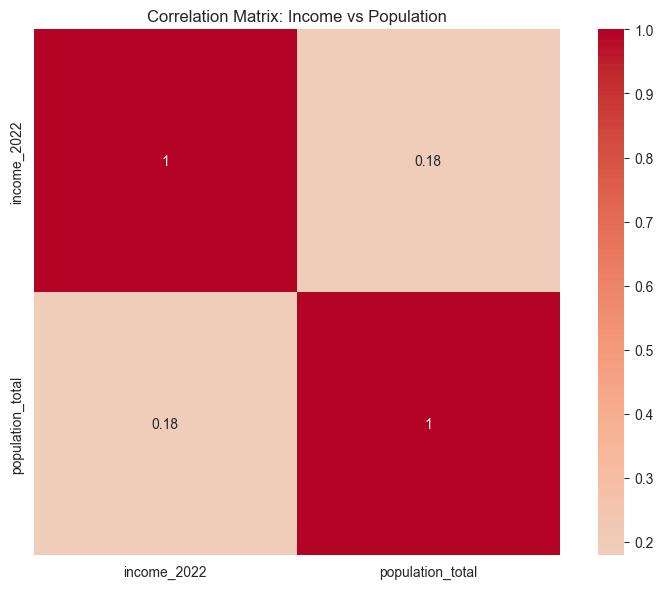

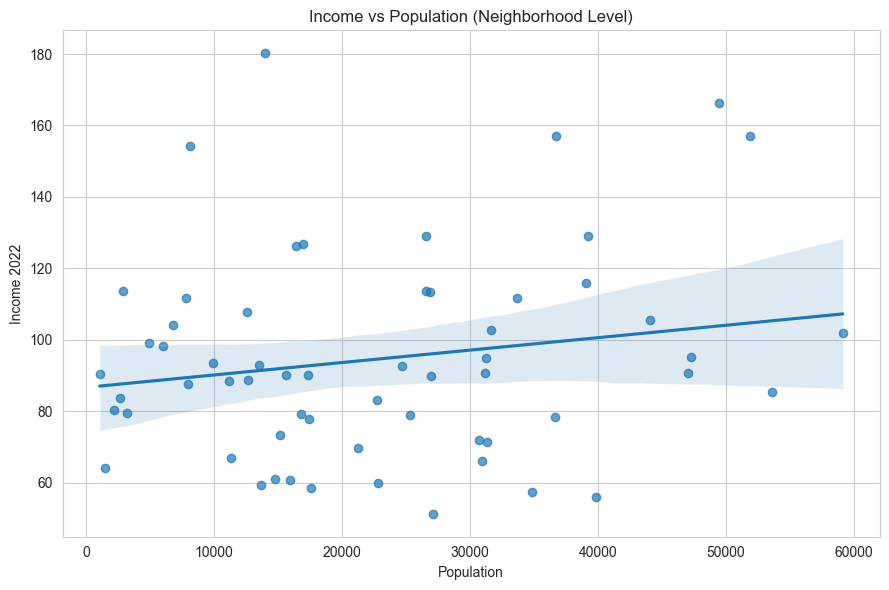


EDA COMPLETE - Maps saved to: ../reports/figures/neighborhoods_income_heatmap.html and ../reports/figures/neighborhoods_population_heatmap.html


In [26]:
print("\n\n### CORRELATION ANALYSIS ###")

corr_df = analysis_gdf[["income_2022", "population_total"]].dropna()

if len(corr_df) > 1:
    corr_matrix = corr_df.corr()
    print("\nCorrelation Matrix:")
    print(corr_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, square=True)
    plt.title("Correlation Matrix: Income vs Population")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 6))
    sns.regplot(data=corr_df, x="population_total", y="income_2022", scatter_kws={"alpha": 0.7})
    plt.title("Income vs Population (Neighborhood Level)")
    plt.xlabel("Population")
    plt.ylabel("Income 2022")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough complete rows to compute correlations.")

print("\n" + "=" * 60)
print("EDA COMPLETE - Maps saved to: ../reports/figures/neighborhoods_income_heatmap.html and ../reports/figures/neighborhoods_population_heatmap.html")
print("=" * 60)